In [1]:
import functions as fc

In [ ]:
import os
import uproot

import numpy as np
import pandas as pd

from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Process the trigggers (.root) and glitches (.csv) and save as .csv

In [ ]:
folder = "/home/esanches/Projetos/tSNE/Virgo/zomicron"
exit_csv = "/home/esanches/Projetos/tSNE/Virgo/triggers_total.csv"

files = [f for f in os.listdir(folder) if f.endswith(".root")]

first = True

for arq in files:
    print(f"Reading: {arq}")
    caminho = os.path.join(folder, arq)
    
    with uproot.open(caminho) as f:
        tree = f["triggers;1"]
        df = tree.arrays(["time", "frequency", "snr"], library="pd")
        
    df.to_csv(exit_csv, mode="w" if first else "a", header=first, index=False)

    first = False
    del df

and the glitches .csv arquives

In [ ]:
pasta = "/home/esanches/Projetos/tSNE/Virgo/our_clustering"
files = glob.glob(os.path.join(pasta, "Clustered_*.csv"))

saida_csv = "/home/esanches/Projetos/tSNE/Virgo/gdchar.csv"
first = True   # write the header only one time

for f in files:
    print(f"Reading: {f}")
    
    df = pd.read_csv(f, header=0)
    df.to_csv(saida_csv, mode='w' if first else 'a', header=first, index=False)
    
    first = False
    del df

## Read and apply filters to triggers and glitches

In [63]:
tperc = 0.7
gperc = 1.0
trigg_size = 359385802
glit_size = 80399   
trigcols = ['time', 'frequency', 'snr']
glitcols = ['GPStime', 'centralFreq', 'snr', 'label', 'confidence']

In [64]:
ntrig, nglit = int(trigg_size*tperc), int(glit_size*gperc)
path = '/home/esanches/Projetos/tSNE/Virgo/'

In [65]:
np.random.seed(42)
skip_logic = lambda i: i > 0 and np.random.random() > tperc

In [66]:
trigg = pd.read_csv(path + "triggers_total.csv", skiprows=skip_logic, usecols=trigcols)
trigg = trigg.sort_values('time').reset_index(drop=True)

unclustered = trigg.copy()

In [67]:
unclustered

,time,frequency,snr
0,1.238165e+09,1421.921349,5.009650
1,1.238165e+09,1013.443826,5.133190
2,1.238165e+09,396.149524,5.064613
3,1.238165e+09,396.149524,5.281003
4,1.238165e+09,388.226028,5.152806
...,...,...,...
251583700,1.269672e+09,1426.656564,6.905275
251583701,1.269672e+09,474.735572,55.750837
251583702,1.269672e+09,1280.344030,8.660046
251583703,1.269672e+09,1079.892919,15.370766


In [68]:
glit = pd.read_csv(path + 'gspy.csv', usecols=glitcols)

In [69]:
glit = glit.drop(glit[glit['label'].isin(['None_of_the_Above', 'No_Glitch'])].index)
glit = glit[glit['confidence'] >= 0.9]
top10 = glit['label'].value_counts().head(10).index
glit = glit[glit['label'].isin(top10)].copy()

In [70]:
glit = glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)

In [71]:
limited_glit = glit.groupby('label', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42))

limited_glit = limited_glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)
clustered = limited_glit.copy()

In [72]:
clustered

,GPStime,snr,centralFreq,confidence,label
0,1.238166e+09,12.088,211.877,1.000,Blip
1,1.238168e+09,24.299,421.424,1.000,Whistle
2,1.238169e+09,21.492,353.844,0.998,Whistle
3,1.238178e+09,8.201,23.028,0.989,Low_Frequency_Lines
4,1.238179e+09,10.690,181.356,1.000,Blip
...,...,...,...,...,...
8832,1.253967e+09,8.355,30.352,1.000,Scattered_Light
8833,1.253971e+09,7.899,20.195,0.998,Low_Frequency_Lines
8834,1.253973e+09,7.946,26.140,0.960,Low_Frequency_Burst
8835,1.253974e+09,12.798,592.631,1.000,Scattered_Light


## Create glitchgrams

In [134]:
def glitch_to_glitchgram(unclustered, clustered, deltat, 
                         fmin=3, fmax=8192, tbins=41, fbins=30):
    """
    This function create one glitchgram from unclustered Omicron data, for each glitch.

    Parameters:
        df_triggers (dataFrame): A dataFrame of GPStimes of all triggers inside of some window.
        tmin, tmax (numbers): limits of GPStimes that contain all triggers of some glitch.
        fmin, fmax (numbers): frequency range for the glitchgram.
        n_time_bins (int): number of time bins.
        n_freq_bins (int): number of frequency bins.
        norm (boolean): True if you need normalize SNR values.

    Returns:
        array for some glitch: each entry is a SNR value from flattened (binsf × binst) matrix.
    """

    times_all = unclustered['time'].values
    freqs_all = unclustered['frequency'].values
    snrs_all  = unclustered['snr'].values

    vecs = []
    labs = []
    GPSs = []

    time_edges = np.linspace(-deltat/2, deltat/2, tbins+1)
    freq_edges = np.logspace(np.log10(fmin), np.log10(fmax), fbins+1)
    
    for i, row in enumerate(clustered.itertuples(index=False)):

        #t_center = getattr(row, 'GPStime')
        t_center = row.GPStime
    
        tmin = t_center - deltat/2
        tmax = t_center + deltat/2
    
        i0 = np.searchsorted(times_all, tmin, side="left")
        i1 = np.searchsorted(times_all, tmax, side="right")
    
        times = times_all[i0:i1] - t_center
        freqs = freqs_all[i0:i1]
        snrs  = snrs_all[i0:i1]

        if len(times) < 10: # Equivalente ao tcut
            continue
    
        df_triggers = pd.DataFrame({'time': times,'frequency': freqs,'snr': snrs})
        
        t_idx = np.digitize(df_triggers['time'].values, time_edges) - 1
        f_idx = np.digitize(df_triggers['frequency'].values, freq_edges) - 1
            
        # initial empty matrix
        A = np.zeros((fbins, tbins), dtype=float)
    
        for ti, fi, si in zip(t_idx, f_idx, snrs):
            if 0 <= ti < tbins and 0 <= fi < fbins:
                if si > A[fi, ti]:
                    A[fi, ti] = si
                    
        '''# normalização do SNR 
        if len(snrs) > 0:
            snr_min = snrs.min()
            snr_max = snrs.max()
            if snr_max > snr_min:
                norm_snrs = (snrs - snr_min) / (snr_max - snr_min)
            else:
                norm_snrs = np.zeros_like(snrs)
        else:
            norm_snrs = snrs'''
        
        vecs.append(A.flatten(order="C"))
        labs.append(clustered['label'][i])
        GPSs.append(clustered['GPStime'][i])

    vecs_final = np.array(vecs).astype('float32')
    labs_final = np.array(labs)
    GPSs_final = np.array(GPSs).astype('float32')
    
    savepath = '/home/esanches/Projetos/tSNE/Virgo/teste1/'
    np.save(savepath + 'vecs_gspy.npy', vecs_final)
    np.save(savepath + 'labs_gspy.npy', labs_final)
    np.save(savepath + 'GPSs_gspy.npy', GPSs_final)
    
    return vecs_final, labs_final, GPSs_final

In [135]:
vecs, labs, GPSs = glitch_to_glitchgram(unclustered, clustered, deltat=1, fmin=3, fmax=8192, tbins=41, fbins=30)

## tSNE results

In [24]:
save_path = '/home/esanches/Projetos/tSNE/Virgo/analysis/analysis_II/'

In [25]:
tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=30, learning_rate=200, 
            max_iter=1000, metric="euclidean", random_state=0)

cores_originais = plt.colormaps["tab10"].colors
cmap_lls = ListedColormap(cores_originais[:3])
cmap_ots = ListedColormap(cores_originais[3:10])

In [27]:
# LLS processing

final_vecs1 = np.load(save_path + '/vecs_gspy_lls.npy')
final_labs1 = np.load(save_path + '/labels_gspy_lls.npy')

labs1 = pd.DataFrame(final_labs1, columns=['label'])

# OTS processing

final_vecs2 = np.load(save_path + '/vecs_gspy_ots.npy')
final_labs2 = np.load(save_path + '/labels_gspy_ots.npy')

labs2 = pd.DataFrame(final_labs2, columns=['label'])

In [28]:
# LLS processing

proj1 = tsne.fit_transform(final_vecs1)
le1 = LabelEncoder()
labels1 = le1.fit_transform(labs1.values.ravel())

# OTS processing

proj2 = tsne.fit_transform(final_vecs2)
le2 = LabelEncoder()
labels2 = le2.fit_transform(labs2.values.ravel())

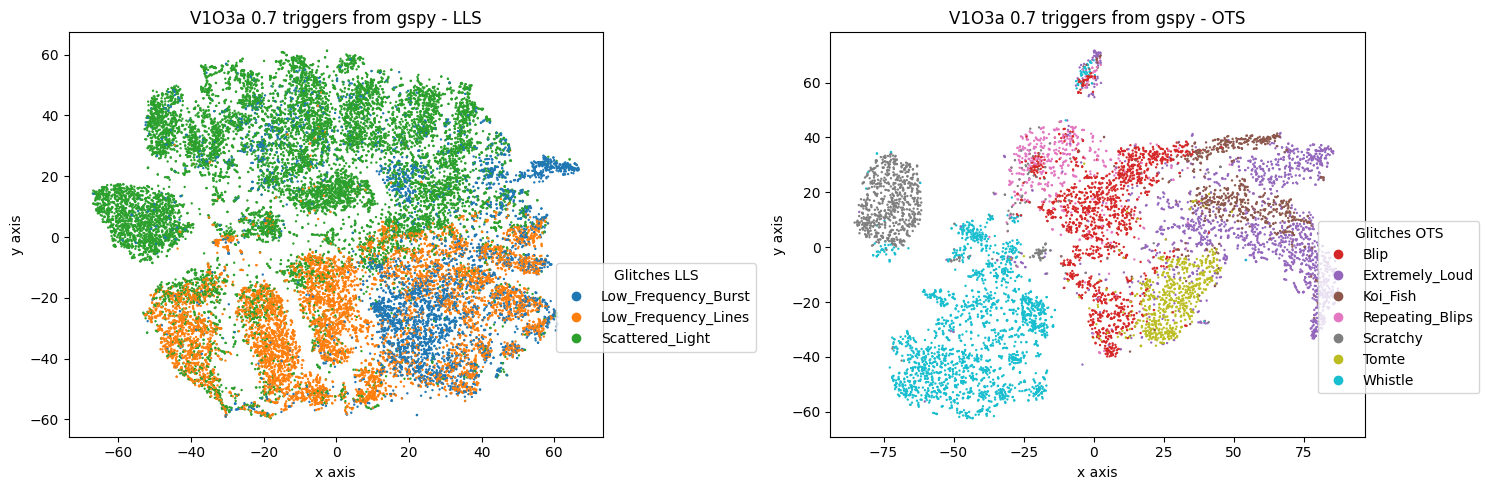

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5)) # Aumentei um pouco para as legendas não sobreporem

sc1 = axs[0].scatter(proj1[:,0], proj1[:,1], s=0.5, c=labels1, cmap=cmap_lls)
axs[0].legend(handles=sc1.legend_elements()[0], labels=list(le1.classes_), title="Glitches LLS", loc='center left', bbox_to_anchor=(0.9, 0.32))
axs[0].set_title('V1O3a 0.7 triggers from gspy - LLS')

sc2 = axs[1].scatter(proj2[:,0], proj2[:,1], s=0.5, c=labels2, cmap=cmap_ots)
axs[1].legend(handles=sc2.legend_elements()[0], labels=list(le2.classes_), title="Glitches OTS", loc='center left', bbox_to_anchor=(0.9, 0.32))
axs[1].set_title('V1O3a 0.7 triggers from gspy - OTS')

for ax in axs:
    ax.set_xlabel('x axis')
    ax.set_ylabel('y axis')

plt.tight_layout()
plt.show()

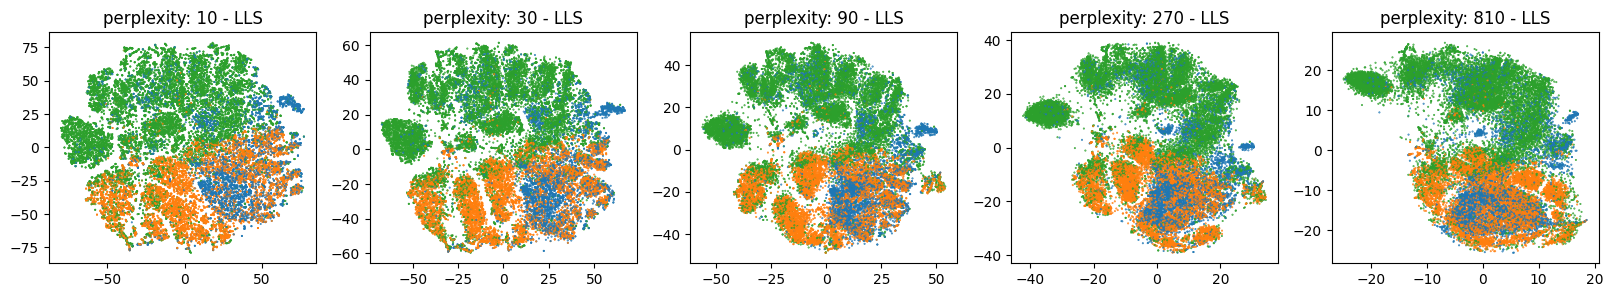

In [34]:
pxs = [10, 30, 90, 270, 810]
fig, axs = plt.subplots(1, len(pxs), figsize=(4*len(pxs), 3))

le = LabelEncoder()
labels = le.fit_transform(final_labs1)

for i, p in enumerate(pxs):

    tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=p, learning_rate=200, 
            max_iter=1000, metric="euclidean", random_state=0)
    proj1 = tsne.fit_transform(final_vecs1)
    
    axs[i].set_title(f'perplexity: {p} - LLS')
    axs[i].scatter(proj1[:,0], proj1[:,1], s=0.2, c=labels, cmap=cmap_lls)

plt.show()

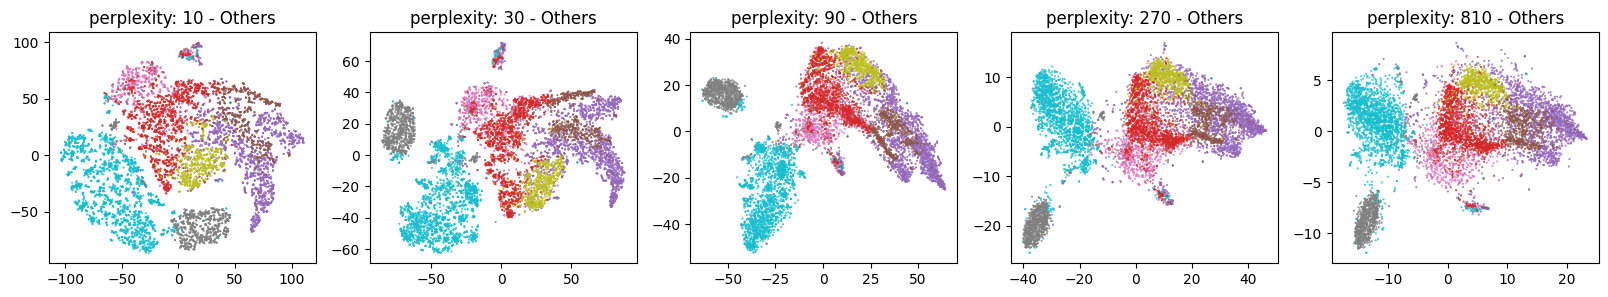

In [33]:
pxs = [10, 30, 90, 270, 810]
fig, axs = plt.subplots(1, len(pxs), figsize=(4*len(pxs), 3))

le = LabelEncoder()
labels = le.fit_transform(final_labs2)

for i, p in enumerate(pxs):

    tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=p, learning_rate=200, 
            max_iter=1000, metric="euclidean", random_state=0)
    proj2 = tsne.fit_transform(final_vecs2)
    
    axs[i].set_title(f'perplexity: {p} - Others')
    axs[i].scatter(proj2[:,0], proj2[:,1], s=0.2, c=labels, cmap=cmap_ots)

plt.show()

In [3]:
savepath = '/home/esanches/Projetos/tSNE/Virgo/teste1/'
final_vecs = np.load(savepath + 'vecs_gspy.npy')

In [5]:
tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=30, learning_rate=200, 
            max_iter=1000, metric="euclidean", random_state=0)

proj = tsne.fit_transform(final_vecs)
proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])

In [6]:
cmap = plt.colormaps["tab10"]
le = LabelEncoder()
labels = le.fit_transform(labs.ravel())

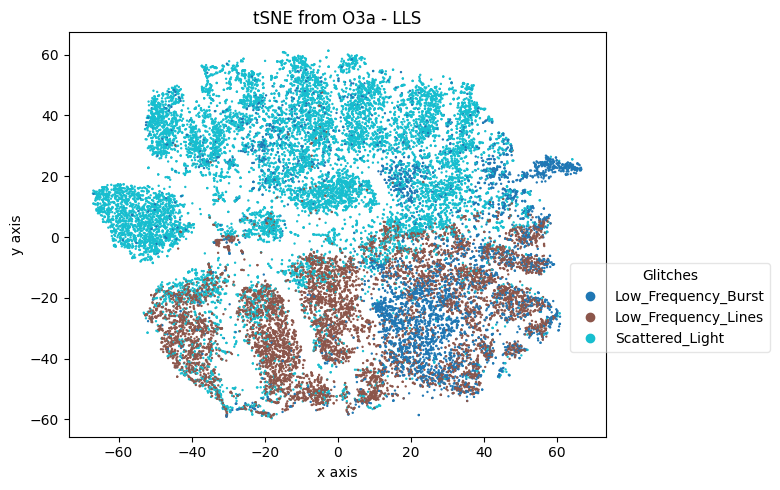

In [7]:
plt.figure(figsize=(8, 5))

sc = plt.scatter(proj_df.values[:,0], proj_df.values[:,1], s=0.5, c=labels, cmap=cmap)
plt.legend(handles=sc.legend_elements()[0], labels=list(le.classes_), title="Glitches", loc='center', framealpha=0.5, markerscale=1.0, bbox_to_anchor=(1.1, 0.32))

plt.title(f'tSNE from gspy - O')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

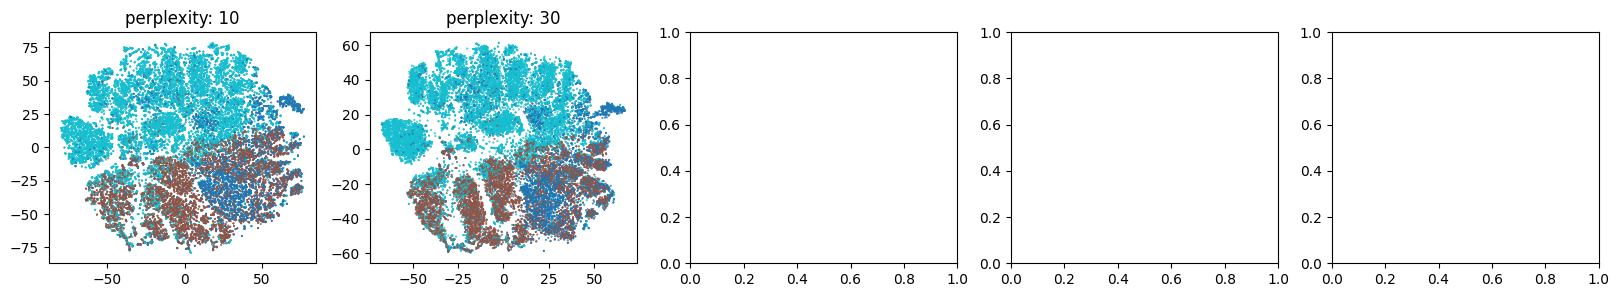

In [ ]:
save_path = '/home/esanches/Projetos/tSNE/Virgo/analysis/analysis_II/'
final_vecs = np.load(save_path + 'vecs_gspy_ots.npy')
final_labs = np.load(save_path + 'labels_gspy_ots.npy')

In [ ]:
save_path = '/home/esanches/Projetos/tSNE/Virgo/teste1/'

final_vecs = np.load(save_path + 'gspy_norm_filtered.npy')

perp = 30

proj_df = func_tSNE(perp, final_vecs)
labs_df = pd.DataFrame(final_labs, columns=['label'])

In [ ]:
#save_path = '/home/esanches/Projetos/tSNE/Virgo/analysis/analysis_I'

#final_vecs = np.load(save_path + '/vecs_gspy.npy')
#final_labs = np.load(save_path + '/labels_gspy.npy')

tsne = TSNE(n_components=2, perplexity=30, metric="euclidean", random_state=0)

proj = tsne.fit_transform(final_vecs)
proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])